In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score, r2_score,
    classification_report,
)

sns.set_theme(style="whitegrid")
SEED = 42

In [2]:
# Load
df = pd.read_excel('../data/raw/Telco_customer_churn.xlsx', sheet_name='Telco_Churn')
print(f"Raw shape: {df.shape}")

# Drop columns specified by user + City (high cardinality string, not in encode list)
# + Churn Label (text version of the target — we predict Churn Value instead)
# + Total Charges (multicollinearity with Tenure Months — see ML_experiments_decisions.md)
# Latitude and Longitude are kept as continuous geographic features
cols_to_drop = [
    "Count", "Country", "State", "Lat Long",
    "Churn Score", "Churn Reason",
    "City",          # 1 129 unique string values, not in the encode list
    "Churn Label",   # text mirror of Churn Value — leaks the target
    "Total Charges", # high collinearity with Tenure Months (r=0.83, VIF>10)
]
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

print(f"Shape after drops: {df.shape}")
display(df.head())

Raw shape: (7043, 33)
Shape after drops: (7043, 24)


,CustomerID,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Churn Value,CLTV
0,3668-QPYBK,90003,33.964131,-118.272783,Male,No,No,No,2,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,1,3239
1,9058-HRZSV,91706,34.098275,-117.967399,Female,Yes,Yes,No,65,Yes,...,Yes,No,No,Yes,Month-to-month,No,Electronic check,94.40,0,5348
2,4767-HZZHQ,90277,33.830453,-118.384565,Male,No,Yes,Yes,30,Yes,...,Yes,No,No,No,Month-to-month,No,Bank transfer (automatic),82.05,0,5036
3,8734-DKSTZ,92283,32.852947,-114.850784,Female,No,Yes,Yes,10,Yes,...,No,No,No,Yes,Month-to-month,No,Electronic check,85.95,0,4922
4,0913-XWSCN,92585,33.739412,-117.173334,Male,No,Yes,Yes,55,Yes,...,No,No,No,Yes,Month-to-month,No,Bank transfer (automatic),85.50,0,6411


In [3]:
# One-hot encode categorical columns
cat_cols = [
    "Gender", "Senior Citizen", "Partner", "Dependents",
    "Phone Service", "Multiple Lines", "Internet Service",
    "Online Security", "Online Backup", "Device Protection",
    "Tech Support", "Streaming TV", "Streaming Movies",
    "Contract", "Paperless Billing", "Payment Method",
]
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Features / target split — exclude CustomerID and target
X = df.drop(columns=["CustomerID", "Churn Value"]).astype(float)
y = df["Churn Value"]

# 80 / 20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"Train shape : {X_train.shape}")
print(f"Test  shape : {X_test.shape}")
# y.mean() on a 0/1 column = proportion of churned customers
print(f"Train churn rate : {y_train.mean():.2%}")
print(f"Test  churn rate : {y_test.mean():.2%}")

# Standardize — fit only on train to avoid data leakage into test
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("\nStandardization done — mean≈0, std≈1 on training set")

Train shape : (5634, 33)
Test  shape : (1409, 33)
Train churn rate : 26.54%
Test  churn rate : 26.54%

Standardization done — mean≈0, std≈1 on training set


In [4]:
def compute_metrics(y_true, y_pred, y_prob=None, model_name="Model"):
    """Return a labelled Series of classification + regression-style metrics."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # MAPE and MRE are undefined when y_true == 0; restrict to positive class rows
    mask = y_true != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
        mre  = np.mean((y_pred[mask] - y_true[mask]) / y_true[mask]) * 100
    else:
        mape = mre = float("nan")

    metrics = {
        "Accuracy"   : accuracy_score(y_true, y_pred),
        "Precision"  : precision_score(y_true, y_pred, zero_division=0),
        "Recall"     : recall_score(y_true, y_pred, zero_division=0),
        "F1"         : f1_score(y_true, y_pred, zero_division=0),
        "R²"         : r2_score(y_true, y_pred),
        "MAPE (%)"   : round(mape, 4),
        "MRE (%)"    : round(mre, 4),
    }
    if y_prob is not None:
        metrics["AUC-ROC"] = roc_auc_score(y_true, y_prob)
        metrics["PR-AUC"]  = average_precision_score(y_true, y_prob)

    return pd.Series(metrics, name=model_name)

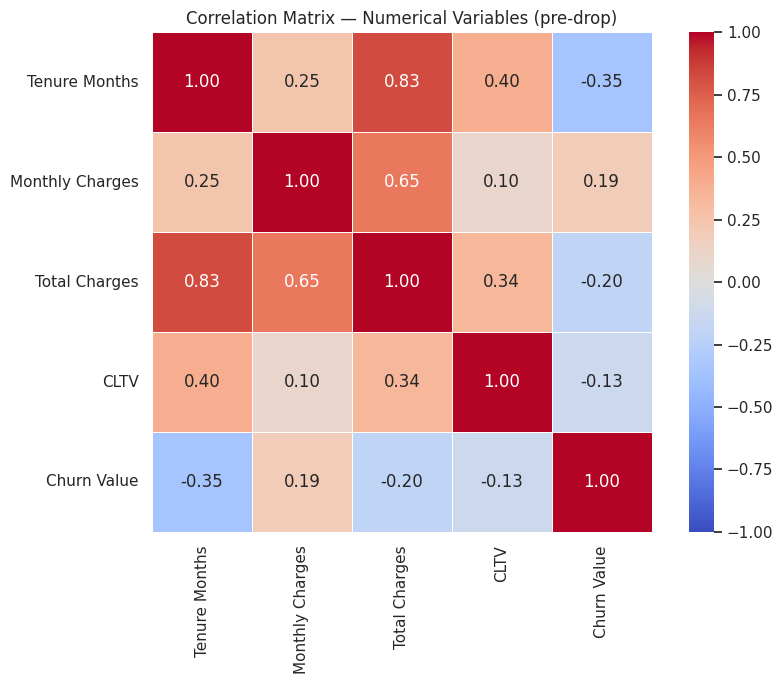

,Tenure Months,Monthly Charges,Total Charges,CLTV,Churn Value
Tenure Months,1.00,0.25,0.83,0.40,-0.35
Monthly Charges,0.25,1.00,0.65,0.10,0.19
Total Charges,0.83,0.65,1.00,0.34,-0.20
CLTV,0.40,0.10,0.34,1.00,-0.13
Churn Value,-0.35,0.19,-0.20,-0.13,1.00



Variance Inflation Factor (VIF)  —  threshold: VIF > 10 indicates problematic multicollinearity


,Feature,VIF
0,Tenure Months,12.715480
1,Total Charges,12.602832
2,Monthly Charges,9.676597
3,CLTV,9.400738


In [5]:
# Correlation + VIF — numerical variables (including target)
# Uses a temporary raw load so Total Charges can be shown before its drop is applied
from statsmodels.stats.outliers_influence import variance_inflation_factor

_df_raw = pd.read_excel('../data/raw/Telco_customer_churn.xlsx', sheet_name='Telco_Churn')
_df_raw["Total Charges"] = pd.to_numeric(_df_raw["Total Charges"], errors="coerce")
_df_raw["Churn Value"] = _df_raw["Churn Value"].astype(float)

num_cols_corr = ["Tenure Months", "Monthly Charges", "Total Charges", "CLTV", "Churn Value"]

# Correlation heatmap
corr = _df_raw[num_cols_corr].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Correlation Matrix — Numerical Variables (pre-drop)")
plt.tight_layout()
plt.show()

display(corr.style.background_gradient(cmap="coolwarm", vmin=-1, vmax=1).format("{:.2f}"))

# VIF — computed on numerical feature columns before any drops
vif_cols = ["Tenure Months", "Monthly Charges", "Total Charges", "CLTV"]
vif_data = _df_raw[vif_cols].dropna().astype(float)

vif_df = pd.DataFrame({
    "Feature": vif_cols,
    "VIF": [variance_inflation_factor(vif_data.values, i) for i in range(len(vif_cols))],
}).sort_values("VIF", ascending=False).reset_index(drop=True)

print("\nVariance Inflation Factor (VIF)  —  threshold: VIF > 10 indicates problematic multicollinearity")
display(vif_df)

del _df_raw

In [6]:
# Dummy Classifier
dummy = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy.fit(X_train_scaled, y_train)

y_pred_dummy = dummy.predict(X_test_scaled)
y_prob_dummy = dummy.predict_proba(X_test_scaled)[:, 1]

print("=== Dummy Classifier ===")
print(classification_report(y_test, y_pred_dummy, target_names=["No Churn", "Churn"]))
display(compute_metrics(y_test, y_pred_dummy, y_prob_dummy, "Dummy Classifier").to_frame())

=== Dummy Classifier ===
              precision    recall  f1-score   support

    No Churn       0.73      1.00      0.85      1035
       Churn       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409



/home/gabe/workspace/telco-churn-challenge/notebooks/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gabe/workspace/telco-churn-challenge/notebooks/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gabe/workspace/telco-churn-challenge/notebooks/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parame

,Dummy Classifier
Accuracy,0.734564
Precision,0.000000
Recall,0.000000
F1,0.000000
R²,-0.361353
MAPE (%),100.000000
MRE (%),-100.000000
AUC-ROC,0.500000
PR-AUC,0.265436


In [7]:
# Logistic Regression — classification threshold lowered to 0.3
# Justification: see ML_experiments_decisions.md
THRESHOLD = 0.3

lr = LogisticRegression(random_state=SEED, max_iter=10000)
lr.fit(X_train_scaled, y_train)

y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
y_pred_lr = (y_prob_lr >= THRESHOLD).astype(int)

print("=== Logistic Regression (threshold=0.3) ===")
print(classification_report(y_test, y_pred_lr, target_names=["No Churn", "Churn"]))
display(compute_metrics(y_test, y_pred_lr, y_prob_lr, "Logistic Regression").to_frame())

=== Logistic Regression (threshold=0.3) ===
              precision    recall  f1-score   support

    No Churn       0.90      0.76      0.83      1035
       Churn       0.54      0.78      0.64       374

    accuracy                           0.77      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.77      0.78      1409



,Logistic Regression
Accuracy,0.765082
Precision,0.540037
Recall,0.775401
F1,0.636663
R²,-0.204834
MAPE (%),22.459900
MRE (%),-22.459900
AUC-ROC,0.856093
PR-AUC,0.690129


/home/gabe/workspace/telco-churn-challenge/notebooks/.venv/lib/python3.10/site-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


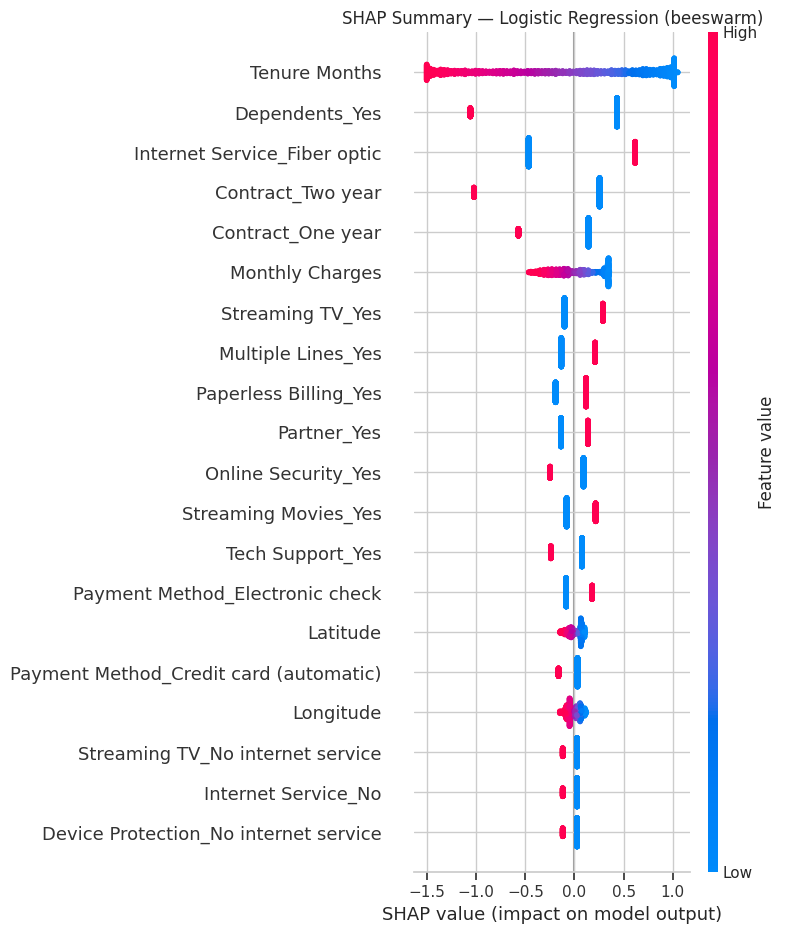

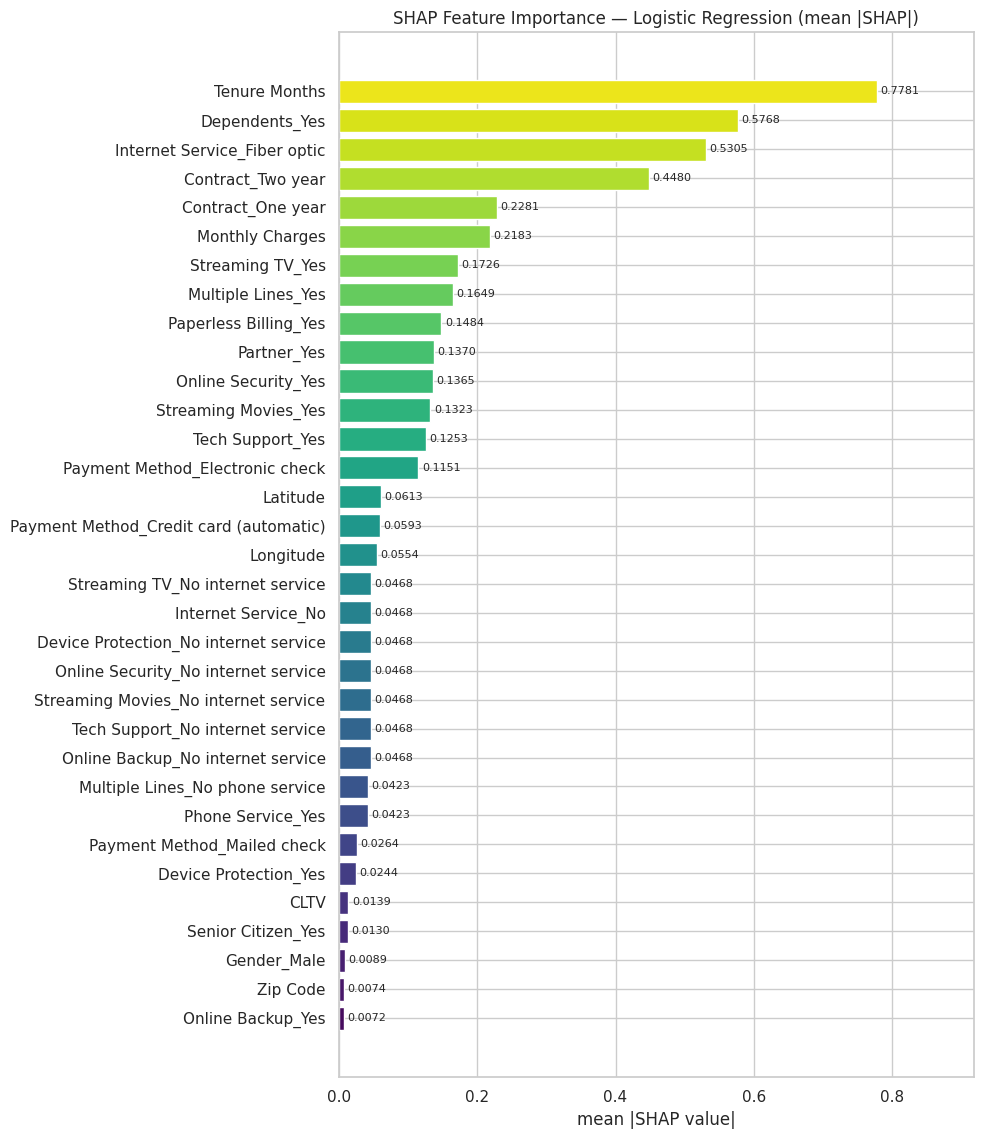

In [8]:
# SHAP values — Logistic Regression feature contributions
import shap

explainer = shap.LinearExplainer(lr, X_train_scaled, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_test_scaled)

feature_names = X.columns.tolist()

# Beeswarm: direction and magnitude per prediction
plt.figure()
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names, show=False)
plt.title("SHAP Summary — Logistic Regression (beeswarm)")
plt.tight_layout()
plt.show()

# Bar: mean absolute SHAP with value labels
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = (
    pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs_shap})
    .sort_values("mean_abs_shap", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, max(6, len(feature_names) * 0.35)))
bars = ax.barh(
    shap_importance["feature"],
    shap_importance["mean_abs_shap"],
    color=sns.color_palette("viridis", len(shap_importance)),
)
for bar, val in zip(bars, shap_importance["mean_abs_shap"]):
    ax.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}",
        va="center", fontsize=8,
    )
ax.set_xlim(0, shap_importance["mean_abs_shap"].max() * 1.18)
ax.set_xlabel("mean |SHAP value|")
ax.set_title("SHAP Feature Importance — Logistic Regression (mean |SHAP|)")
plt.tight_layout()
plt.show()

In [9]:
# MLflow tracking — log this notebook's baseline runs to the shared store
# (same sqlite backend + experiment as src/modeling/train.py, so all runs land together)
import sys, pathlib

sys.path.insert(0, str(pathlib.Path.cwd().parent))  # repo root → makes `src` importable

import mlflow
from src.config import MLFLOW_TRACKING_URI, EXPERIMENT_NAME, THRESHOLD
from src.modeling.metrics import compute_metrics as mlflow_metrics

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

baseline_runs = [
    ("dummy_classifier_nb", {"model_type": "DummyClassifier", "strategy": "most_frequent"},
     y_pred_dummy, y_prob_dummy),
    ("logistic_regression_nb", {"model_type": "LogisticRegression", "threshold": THRESHOLD},
     y_pred_lr, y_prob_lr),
]
for run_name, params, y_pred, y_prob in baseline_runs:
    with mlflow.start_run(run_name=run_name):
        mlflow.set_tag("source", "ML_experiments.ipynb")
        mlflow.log_params(params)
        metrics = mlflow_metrics(y_test, y_pred, y_prob)
        mlflow.log_metrics(metrics)
        print(f"logged {run_name}: {metrics}")

logged dummy_classifier_nb: {'accuracy': 0.7345635202271115, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'auc_roc': 0.5, 'pr_auc': 0.2654364797728886}
logged logistic_regression_nb: {'accuracy': 0.7650816181689141, 'precision': 0.5400372439478585, 'recall': 0.7754010695187166, 'f1': 0.6366630076838639, 'auc_roc': 0.8560928982923868, 'pr_auc': 0.6901289893178808}
